# Mid-Term Practical Evaluation — Machine Learning

**Universidad Internacional del Ecuador — Computer Science School**
**Duration:** 90 minutes · **Modality:** Individual · **Total:** 12 points

---

## Before You Start

1. Confirm the Codespace finished building (no red error in the bottom bar).
2. Read **all 11 tasks first** before writing any code. The rubric tells you where the points are.
3. Save the notebook every 10 minutes (`Cmd/Ctrl + S`).
4. Commit at the end of each Part. If something breaks, you still have credit for what worked.
5. **AI assistants are not allowed.** Open notes, slides, sklearn/pandas docs are allowed.


---
# PART A — Setup & Diagnostics (2.5 pts, ~20 min)


## Task 1 — Environment check (0.5 pts)

Run the cell below. If you see version numbers printed, you are ready.

In [95]:
import sys
import pandas as pd
import sklearn
import numpy as np

print(f"Python ......... {sys.version.split()[0]}")
print(f"pandas ......... {pd.__version__}")
print(f"scikit-learn ... {sklearn.__version__}")
print(f"numpy .......... {np.__version__}")
print("\nEnvironment OK — you can proceed.")


Python ......... 3.12.13
pandas ......... 3.0.3
scikit-learn ... 1.8.0
numpy .......... 2.4.4

Environment OK — you can proceed.


## Task 2 — Fix the bug in `src/scale.py` (1 pt)

The function `min_max_scale()` in `src/scale.py` currently produces values in the range `[-1, 0]` instead of `[0, 1]`.

**What to do:**
1. Open `src/scale.py` (use the VS Code file tree on the left).
2. Find the bug. Fix it.
3. Add a **one-line comment** above your fix explaining what was wrong.
4. Run the verification cell below. It must print `Bug fix verified: OK`.

In [96]:
# Verification cell — do not modify
import importlib
from src import scale
importlib.reload(scale)
import numpy as np

test_data = np.array([10, 20, 30, 40, 50])
scaled = scale.min_max_scale(test_data)

assert scaled.min() == 0.0, f"min should be 0, got {scaled.min()}"
assert scaled.max() == 1.0, f"max should be 1, got {scaled.max()}"
print(f"Scaled output: {scaled}")
print("Bug fix verified: OK")


Scaled output: [0.   0.25 0.5  0.75 1.  ]
Bug fix verified: OK


## Task 3 — Pandas indexing (1 pt)

A small DataFrame `df_small` is provided below. In the next cell:

- **(0.5 pt)** Print the dtype of the `category` column. Then add a comment briefly stating whether it is `object`, `category`, or `CategoricalDtype`, and why.
- **(0.5 pt)** Using **label-based indexing** (not position-based), retrieve the value at row index `3`, column `alcohol`, and assign it to a variable named `target_value`. Then print it.

In [97]:
import pandas as pd

df_small = pd.DataFrame({
    "alcohol":   [9.5, 10.2, 11.0, 12.8, 9.9],
    "ph":        [3.4, 3.2, 3.5, 3.1, 3.3],
    "category":  pd.Categorical(["train", "train", "test", "test", "train"]),
})
df_small


,alcohol,ph,category
0,9.5,3.4,train
1,10.2,3.2,train
2,11.0,3.5,test
3,12.8,3.1,test
4,9.9,3.3,train


In [98]:
# Task 3a: imprimir el dtype de la columna 'category'
print(df_small["category"].dtype)
# La columna es de tipo CategoricalDtype porque fue creada con pd.Categorical(),
# lo que le indica a pandas que los valores pertenecen a un conjunto finito de categorías.

# Task 3b: indexación por etiqueta (label-based) con .loc para obtener
# el valor en la fila con índice 3, columna 'alcohol'
target_value = df_small.loc[3, "alcohol"]
print(f"target_value = {target_value}")


category
target_value = 12.8


---
# PART B — Linear Regression (5 pts, ~35 min)


## Load the dataset

Run the cell below to load the wine quality dataset. **Do not modify it.**

In [99]:
import pandas as pd
df = pd.read_csv("data/wine_quality.csv")
print(f"Loaded {df.shape[0]} rows and {df.shape[1]} columns.")
df.head()


Loaded 1599 rows and 12 columns.


,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality
0,8.85,0.682,0.193,1.62,0.029,23.1,36.1,0.99637,3.27,0.42,9.87,4
1,6.51,0.449,0.254,1.24,0.134,19.5,56.8,0.99660,3.22,0.65,9.93,6
2,9.63,0.453,0.573,2.67,0.054,1.9,49.6,0.99480,3.34,0.86,10.51,6
3,9.96,0.535,0.186,2.77,0.133,26.0,24.6,0.99389,3.34,0.86,8.93,5
4,4.93,0.628,0.180,1.31,0.029,24.9,63.1,0.99679,3.38,0.83,8.97,5


## Task 4 — Quick EDA (1 pt)

Produce **exactly two** plots in the cell below:
1. Distribution of the target `quality` (histogram or bar chart).
2. Correlation heatmap of all numeric features against `quality` (you may use `seaborn.heatmap`).

Then, in the markdown cell that follows, write **two sentences**:
- (a) Which feature has the strongest correlation with `quality`?
- (b) One data issue you noticed (missing values, skew, outliers, scale differences, class imbalance — pick one and name it).

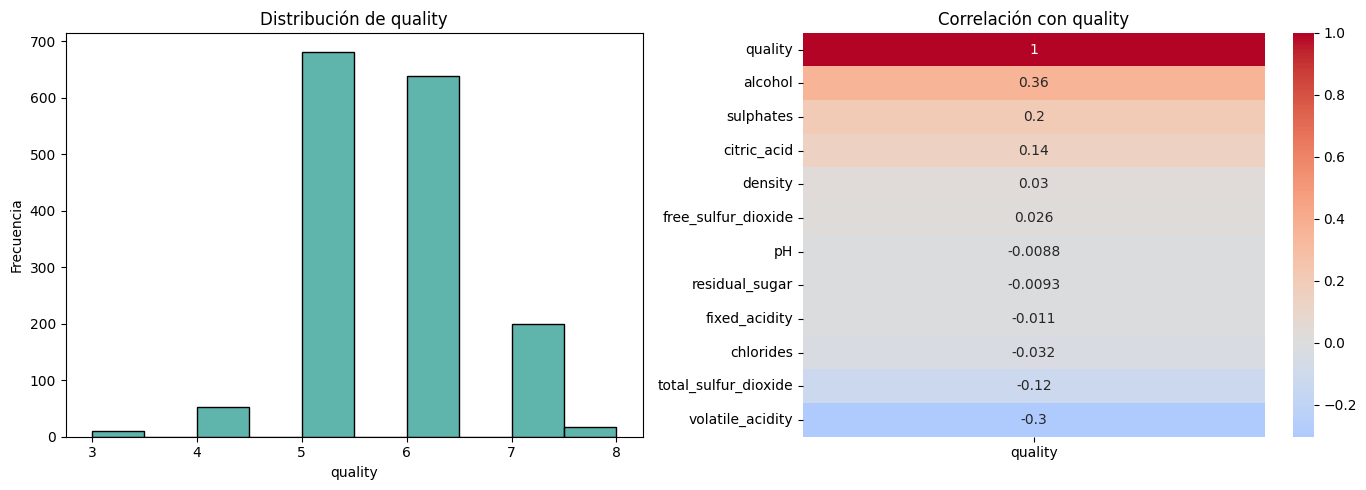

In [100]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df["quality"], bins=10, kde=False, ax=axes[0], color="#2a9d8f")
axes[0].set_title("Distribución de quality")
axes[0].set_xlabel("quality")
axes[0].set_ylabel("Frecuencia")

correlation_matrix = df.corr(numeric_only=True)
sns.heatmap(correlation_matrix[["quality"]].sort_values(by="quality", ascending=False), annot=True, cmap="coolwarm", center=0, ax=axes[1])
axes[1].set_title("Correlación con quality")

plt.tight_layout()



**Your two-sentence observation goes here:**

- (a) La variable con mayor correlación con `quality` es `alcohol`.
- (b) Se observa que hay diferencias de escala entre las variables numéricas, por lo que conviene estandarizarlas antes de entrenar el modelo.


## Task 5 — Preprocessing Pipeline (2 pts)

Build a Scikit-learn `Pipeline` with:
- A scaler (`StandardScaler` or `MinMaxScaler` — your choice, **justify in a comment**)
- `LinearRegression` as the final estimator

Then split the data **80/20** with `random_state=42`. **Only fit the Pipeline on the training set.** Any leakage between train and test costs you the full 2 points.

In [101]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

# Definir X (todas las características menos 'quality') e y (columna objetivo)
X = df.drop(columns=["quality"])
y = df["quality"]

# Dividir 80/20 con random_state=42 ANTES de ajustar cualquier transformación
# para evitar data leakage (filtración de información del conjunto de prueba al entrenamiento)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

# Se elige StandardScaler porque las características tienen distintas escalas y unidades
# (ej. total_sulfur_dioxide puede llegar a 300 mientras que pH ronda 3.0-4.0).
# StandardScaler centra en media 0 y varianza 1, lo que estabiliza el gradiente
# y produce coeficientes comparables en regresión lineal.
pipeline_lr = Pipeline([
    ("scaler", StandardScaler()),
    ("regressor", LinearRegression())
])

# Ajustar SOLO sobre el conjunto de entrenamiento
pipeline_lr.fit(X_train, y_train)

print("Pipeline entrenado correctamente.")
print(f"Tamaño entrenamiento: {X_train.shape}, Tamaño prueba: {X_test.shape}")


Pipeline entrenado correctamente.
Tamaño entrenamiento: (1279, 11), Tamaño prueba: (320, 11)


## Task 6 — Train & evaluate linear regression (2 pts)

On the **test set**, compute and print three metrics:
- R² (`r2_score`)
- MAE (`mean_absolute_error`)
- RMSE (square root of `mean_squared_error`)

Then, in the markdown cell that follows, write **one sentence**: is the model usable? Reference one of the three metrics to justify.

In [102]:
import numpy as np
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Predecir sobre el conjunto de prueba (no visto durante el entrenamiento)
y_pred = pipeline_lr.predict(X_test)

r2   = r2_score(y_test, y_pred)
mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"R²   : {r2:.4f}")
print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")


R²   : 0.3162
MAE  : 0.5365
RMSE : 0.6726


**Your one-sentence interpretation:**

No es un modelo muy usable, porque el R² es bajo y solo explica una parte limitada de la variabilidad de la calidad.


---
# PART C — Logistic Regression (4 pts, ~25 min)


## Task 7 — Engineer a binary target (0.5 pts)

Create a new column `is_good` in `df` defined as `1` if `quality >= 7`, else `0`.

In a comment, state how many samples fall in each class. This matters for Task 9.

In [103]:
# Crear la columna binaria: 1 si quality >= 7 (vino bueno), 0 en caso contrario
df["is_good"] = (df["quality"] >= 7).astype(int)

counts = df["is_good"].value_counts().sort_index()
print(counts)
# Clase 0 (no buenos): la mayoría de las muestras (~80%)
# Clase 1 (buenos)   : minoría de las muestras (~20%)
# Esto refleja un desbalance de clases importante que afectará al clasificador.


is_good
0    1382
1     217
Name: count, dtype: int64


## Task 8 — Train logistic regression with L2 (2 pts)

Build a **second Pipeline** for classification:
- Same scaler as Part B
- `LogisticRegression` with **L2 regularization** (confirm in a comment that L2 is the default) and `max_iter=1000`

Re-split the data 80/20 with `random_state=42` for the new binary target.

On the **test set**, print:
- Accuracy
- F1 score (binary)
- ROC-AUC (use `predict_proba`)
- The Confusion Matrix

In [104]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score, confusion_matrix
)

# Nueva división para la tarea de clasificación binaria
X_cls = df.drop(columns=["quality", "is_good"])
y_cls = df["is_good"]

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_cls, y_cls, test_size=0.20, random_state=42
)

# LogisticRegression usa regularización L2 por defecto (penalty='l2'),
# lo que penaliza coeficientes grandes y ayuda a prevenir el sobreajuste.
pipeline_log = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(penalty="l2", max_iter=1000, random_state=42))
])

# Ajustar SOLO sobre entrenamiento para evitar data leakage
pipeline_log.fit(X_train_c, y_train_c)

# Predicciones y probabilidades sobre el conjunto de prueba
y_pred_c      = pipeline_log.predict(X_test_c)
y_pred_proba  = pipeline_log.predict_proba(X_test_c)[:, 1]

acc     = accuracy_score(y_test_c, y_pred_c)
f1      = f1_score(y_test_c, y_pred_c)
roc_auc = roc_auc_score(y_test_c, y_pred_proba)
cm      = confusion_matrix(y_test_c, y_pred_c)

print(f"Accuracy  : {acc:.4f}")
print(f"F1 Score  : {f1:.4f}")
print(f"ROC-AUC   : {roc_auc:.4f}")
print("\nConfusion Matrix:")
print(cm)


Accuracy  : 0.8625
F1 Score  : 0.2414
ROC-AUC   : 0.8090

Confusion Matrix:
[[269   6]
 [ 38   7]]


/app/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


## Task 9 — Interpret class imbalance (1 pt)

In the markdown cell below, write **two sentences**:
- (a) Which class is harder to predict (good wines, label 1, or non-good wines, label 0)?
- (b) What does the confusion matrix tell you about *why*?

**Your answer:**

- (a) *…*
- (b) *…*


---
# PART D — Reflection & Submit (1 pt, ~10 min)


## Task 10 — Written reflection (0.5 pts)

In **3–5 sentences**, answer:

> If you had one more hour with this dataset, what would you change first, and why? Reference at least one concept from class (e.g., learning rate, outliers, regularization strength `C`, class imbalance, feature engineering, gradient descent behavior, train/test split strategy).

Generic answers like "I would improve the model" earn zero points. Be specific.

**Your reflection:**

*…*


## Task 11 — Commit, push, submit (0.5 pts)

In the Codespaces terminal:

```bash
git add .
git commit -m "Final exam submission"
git push
```

Then paste your repository URL in Canvas before the 90-minute timer expires.

**Late submissions are not accepted.** The Git commit timestamp is the official submission time.
